In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings

<function warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

In [38]:
# load the data 
df = pd.read_csv('heart.csv')

## EDA 

In [39]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [40]:
df.shape

(918, 12)

In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [42]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [43]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<Axes: xlabel='HeartDisease'>

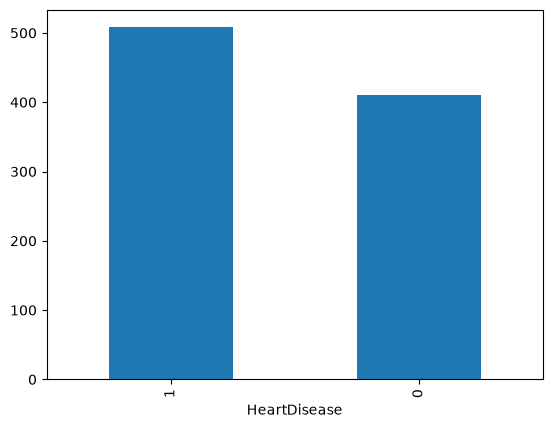

In [46]:
df['HeartDisease'].value_counts().plot(kind='bar')

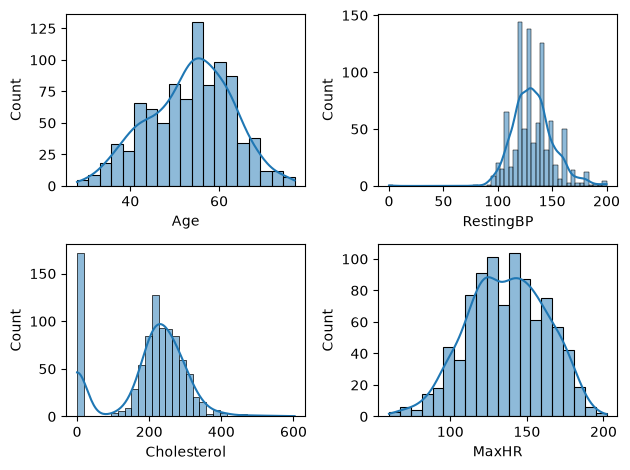

In [47]:
# visalize the numeric colums 
def plotting(val,num):
    plt.subplot(2,2,num)
    sns.histplot(val,kde=True)
    plt.tight_layout()

plotting(df['Age'],1)
plotting(df['RestingBP'],2)
plotting(df['Cholesterol'],3)
plotting(df['MaxHR'],4)

In [48]:
df['Cholesterol'].value_counts()
# basically they fill the missing values with 0 that is a thing so we need to clean this data again

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

## Data Cleaning

In [49]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [50]:
# calculating the mean excluding the 0's
mean_chol = df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()
mean_chol = mean_chol.round(2)
mean_chol

np.float64(244.64)

In [51]:
# replace the 0's by the mean_chol
df['Cholesterol'] = df['Cholesterol'].replace(0,mean_chol)

In [52]:
(df['Cholesterol']==0).sum()

np.int64(0)

In [53]:
# similarly the resting bp cannot be zero
mean_bp = df.loc[df['RestingBP']!=0,'RestingBP'].mean()
mean_bp.round(2)

np.float64(132.54)

In [54]:
df['RestingBP'] = df['RestingBP'].replace(0,mean_bp)

In [55]:
(df['RestingBP']==0).sum()

np.int64(0)

### Again plot the graphs

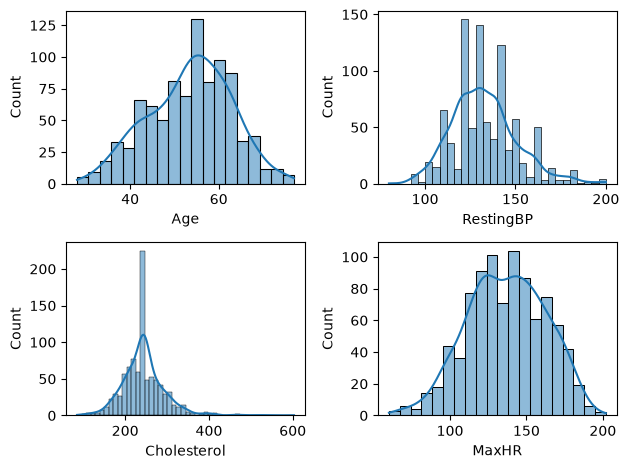

In [56]:
# visalize the numeric colums 
def plotting(val,num):
    plt.subplot(2,2,num)
    sns.histplot(val,kde=True)

plotting(df['Age'],1)
plotting(df['RestingBP'],2)
plotting(df['Cholesterol'],3)
plotting(df['MaxHR'],4)

plt.tight_layout()

# now we all the normal distributed curves

In [57]:
# do the data visualization for the catagorical columns
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


<Axes: xlabel='Sex', ylabel='count'>

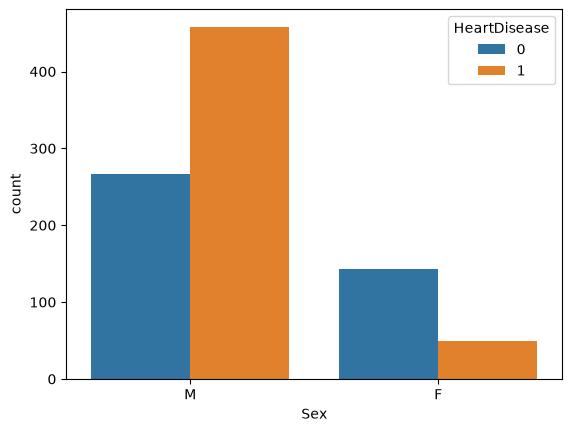

In [58]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

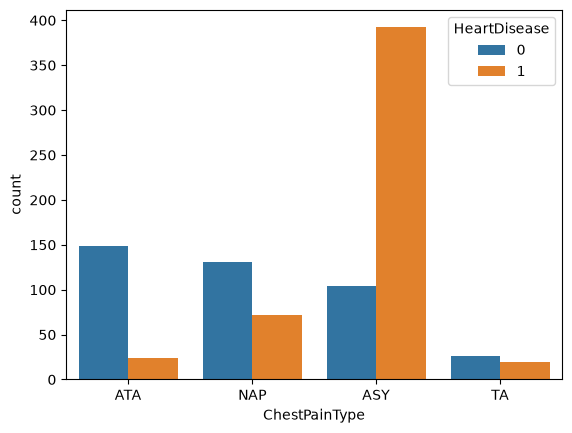

In [59]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

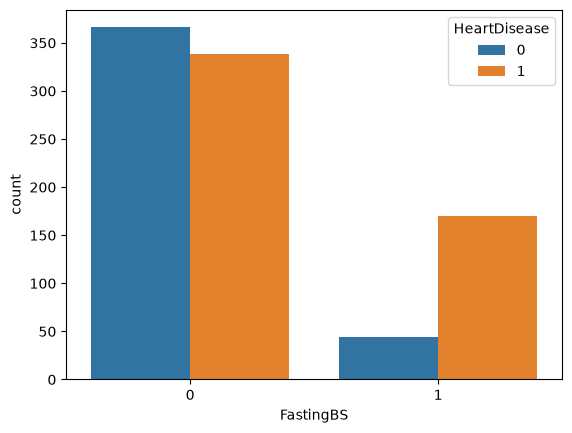

In [60]:
sns.countplot(x = df['FastingBS'],hue = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

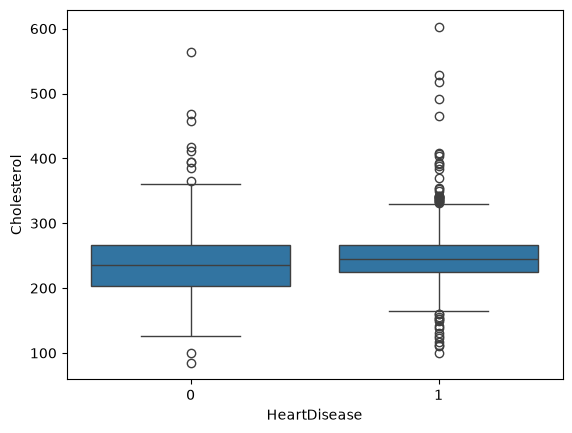

In [61]:
sns.boxplot(x = 'HeartDisease', y = 'Cholesterol',data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

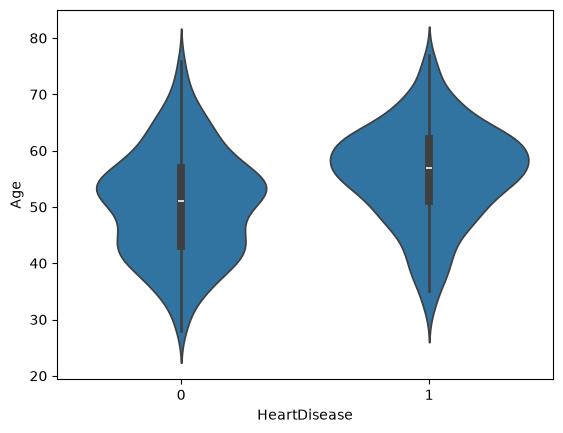

In [62]:

sns.violinplot(x='HeartDisease', y='Age', data=df)

#### calculating the correlation between the numeric columns

In [63]:
df.corr(numeric_only=True)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
Age,1.000000,0.263081,0.053378,0.198039,-0.382045,0.258612,0.282039
RestingBP,0.263081,1.000000,0.083074,0.067811,-0.109662,0.174220,0.117938
Cholesterol,0.053378,0.083074,1.000000,0.043019,-0.017248,0.053028,0.094082
FastingBS,0.198039,0.067811,0.043019,1.000000,-0.131438,0.052698,0.267291
MaxHR,-0.382045,-0.109662,-0.017248,-0.131438,1.000000,-0.160691,-0.400421
Oldpeak,0.258612,0.174220,0.053028,0.052698,-0.160691,1.000000,0.403951
HeartDisease,0.282039,0.117938,0.094082,0.267291,-0.400421,0.403951,1.000000


<Axes: >

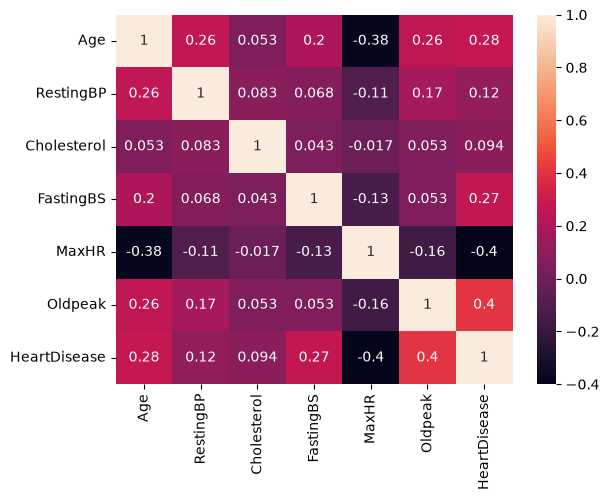

In [64]:
sns.heatmap(data = df.corr(numeric_only=True),annot=True)

## Data Preprocessing and Cleaning

In [65]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [66]:
df_encoded = pd.get_dummies(data = df,drop_first=True,dtype=int)

In [67]:
df_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,1,0,0,1,1,0,0,1,0
914,68,144.0,193.0,1,141,3.4,1,1,0,0,0,1,0,0,1,0
915,57,130.0,131.0,0,115,1.2,1,1,0,0,0,1,0,1,1,0
916,57,130.0,236.0,0,174,0.0,1,0,1,0,0,0,0,0,1,0


### first do the train test split and then apply all the models

In [68]:
from sklearn.model_selection import train_test_split
x = df_encoded.drop('HeartDisease',axis=1)
y = df_encoded['HeartDisease']
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [71]:
# now do the standerd scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [74]:
# now import all the models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    'logistic regression': LogisticRegression(random_state=42),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

In [86]:
# import the evaluation metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score

In [87]:
result =[]

In [88]:
for name, model in models.items():
    model.fit(x_train_scaled,y_train)
    y_pred = model.predict(x_test_scaled)
    acc = accuracy_score(y_true=y_test,y_pred=y_pred)
    f1 = f1_score(y_true=y_test,y_pred=y_pred)

    result.append({
        'model':name,
        'accuracy':acc,
        'f1_score':f1
    })

In [95]:
print(result)

[{'model': 'logistic regression', 'accuracy': 0.8641304347826086, 'f1_score': 0.8792270531400966}, {'model': 'KNN', 'accuracy': 0.8532608695652174, 'f1_score': 0.8708133971291866}, {'model': 'Naive Bayes', 'accuracy': 0.8478260869565217, 'f1_score': 0.8613861386138614}, {'model': 'Decision Tree', 'accuracy': 0.8206521739130435, 'f1_score': 0.8374384236453202}, {'model': 'SVM', 'accuracy': 0.8586956521739131, 'f1_score': 0.8761904761904762}]


In [94]:
for name, model in models.items():
    model.fit(x_train_scaled,y_train)
    y_pred = model.predict(x_test_scaled)
    print(f"Model: {name}")
    print(f"Accuracy: {accuracy_score(y_test,y_pred)}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test,y_pred)}")
    print(f"Classification Report:\n{classification_report(y_test,y_pred)}")
    print("-"*50)

Model: logistic regression
Accuracy: 0.8641304347826086
Confusion Matrix:
[[68  9]
 [16 91]]
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        77
           1       0.91      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184

--------------------------------------------------
Model: KNN
Accuracy: 0.8532608695652174
Confusion Matrix:
[[66 11]
 [16 91]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.86      0.83        77
           1       0.89      0.85      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184

--------------------------------------------------
Model: Naive Bayes
Accuracy: